# Notebook 1 — The SLC26 Superfamily Tree

## Learning objectives
- Understand **orthology/paralogy**
- Build a **phylogenetic pipeline**: alignment → trimming → tree
- Annotate a tree with **NCBI taxonomy** using ETE4
- Identify **orthologs** vs **paralogs** from duplication/speciation events
- Recognize **SLC26 subfamilies** (A1–A11) as paralog clades

## Introduction

## Orthology-Paralogy inference

![Species/Gene tree](../figures/fig1_orthology.png "Species and Gene tree")

**Orthologs**: result from **speciation (S)** and often retain the same function in different species.  

**Paralogs**: derive from gene **duplication (D)**, often creating new, related functions (sub-/neo-functionalization)

### The example of Cytochrome c oxidase I (COX1)

Cytochrome c oxidase I is the main subunit of the cytochrome c oxidase complex. It is often used as a phylogenetic marker / species identifier due to its high conservation. We will use [ETE3](https://etetoolkit.org/) to visualize the gene/protein phylogenetic tree.

In [66]:
from ete3 import PhyloTree

# Load tree — taxid is the part before the dot
t = PhyloTree(open("../data/cox1.nw").read(),
              sp_naming_function=lambda node: node.name.split('.')[0])

# Root at midpoint
t.set_outgroup(t.get_midpoint_outgroup())

print(t)


   /-7227.P00399
--|
  |   /-9606.P00395
   \-|
      \-10090.P00397


In [43]:
# Annotate with NCBI taxonomy (downloads DB on first run)
print("Annotating with NCBI taxonomy...")
annotation = t.annotate_ncbi_taxa()

Annotating with NCBI taxonomy...


In [44]:
print(t.get_ascii(attributes=['sci_name', "name"]))


           /-Drosophila melanogaster, 7227.P00399
-Bilateria, 
          |                  /-Homo sapiens, 9606.P00395
           \Euarchontoglires, 
                             \-Mus musculus, 10090.P00397


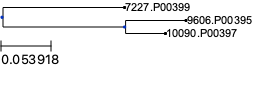

In [46]:
t.render("%%inline")

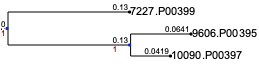

In [48]:
from ete3 import TreeStyle

ts = TreeStyle()
ts.show_leaf_name = False
ts.show_scale = False
ts.show_branch_length = True
ts.show_branch_support = True

t.render("%%inline", tree_style=ts)

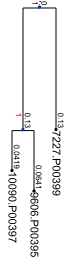

In [49]:
ts.rotation = 90
t.render("%%inline", tree_style=ts)

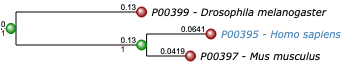

In [58]:
from ete3 import faces

def mylayout(node):
   if node.is_leaf():
      # Draw terminal nodes as small red spheres of diameter equal to 10 pixels
      node.img_style['size'] = 10
      node.img_style["shape"] = "sphere"
      node.img_style["fgcolor"] = "darkred"
      # TextFace
      name = faces.TextFace(f"{node.name.split('.')[1]} - {node.sci_name}", fstyle="italic")
      name.margin_left = 5
      if node.taxid == 9606:
         name.fgcolor = "steelblue"
      faces.add_face_to_node(name, node, column=0)
   else:
      node.img_style['size'] = 10
      node.img_style["shape"] = "sphere"
      node.img_style["fgcolor"] = "green"

ts = TreeStyle()
ts.show_leaf_name = False
ts.show_scale = False
ts.show_branch_length = True
ts.show_branch_support = True

t.render("%%inline", tree_style=ts, layout=mylayout)

In [56]:
events = t.get_descendant_evol_events()

# Traversing (browsing) trees
# "postorder", "preorder" or "levelorder"
for node in t.traverse():
    if 'evoltype' in node.features:
        print(node.name, node.features)

 {'sci_name', 'rank', 'named_lineage', 'support', 'common_name', 'lineage', 'dist', 'name', 'taxid', 'evoltype', '_nid'}
 {'sci_name', 'rank', 'named_lineage', 'support', 'common_name', 'lineage', 'dist', 'name', 'taxid', 'evoltype', '_nid'}


In [57]:
print(t.get_ascii(attributes=['evoltype', "name"]))


   /-7227.P00399
-S, 
  |   /-9606.P00395
   \S, 
      \-10090.P00397


### The SLC23A family of ascorbate transporters (uptake of vitamin C)

In [79]:
# Load tree — taxid is the part before the dot
t = PhyloTree(open("../data/slc23a.nw").read(),
              sp_naming_function=lambda node: node.name.split('.')[0])

# Root at midpoint
print("Midpoint rooting...")
t.set_outgroup(t.get_midpoint_outgroup())

print("Annotating with NCBI taxonomy...")
annotation = t.annotate_ncbi_taxa()

print(t.get_ascii(attributes=["name", "sci_name"]))

Midpoint rooting...
Annotating with NCBI taxonomy...

                             /-10090.Q60850, Mus musculus
           /, Euarchontoglires
          |                  \-9606.Q6PIS1, Homo sapiens
          |
          |                                               /-10090.Q9EPR4, Mus musculus
-, Bilateria                            /, Euarchontoglires
          |                            |                  \-9606.Q9UGH3, Homo sapiens
          |           /, Euarchontoglires
          |          |                 |                  /-9606.Q9UHI7, Homo sapiens
          |          |                  \, Euarchontoglires
           \, Bilateria                                   \-10090.Q9Z2J0, Mus musculus
                     |
                     |           /-7227.Q9VH02, Drosophila melanogaster
                      \, Bilateria
                                 \-10090.A0A0J9YUX7, Mus musculus


Root the tree in _Drosophila melanogaster_ sequence

In [81]:
# Set 7227.Q9VH02 as outgroup
t.set_outgroup("7227.Q9VH02")

print(t.get_ascii(attributes=["name", "sci_name"]))


           /-7227.Q9VH02, Drosophila melanogaster
          |
          |           /-10090.A0A0J9YUX7, Mus musculus
-, Bilateria         |
          |          |                                               /-10090.Q9EPR4, Mus musculus
          |          |                             /, Euarchontoglires
           \, Bilateria                           |                  \-9606.Q9UGH3, Homo sapiens
                     |           /, Euarchontoglires
                     |          |                 |                  /-9606.Q9UHI7, Homo sapiens
                     |          |                  \, Euarchontoglires
                      \, Bilateria                                   \-10090.Q9Z2J0, Mus musculus
                                |
                                |                  /-10090.Q60850, Mus musculus
                                 \, Euarchontoglires
                                                   \-9606.Q6PIS1, Homo sapiens


In [82]:
# Annotate with NCBI taxonomy AGAIN and see difference
t.annotate_ncbi_taxa()

print(t.get_ascii(attributes=["name", "sci_name"]))


           /-7227.Q9VH02, Drosophila melanogaster
          |
          |                  /-10090.A0A0J9YUX7, Mus musculus
-, Bilateria                |
          |                 |                                                      /-10090.Q9EPR4, Mus musculus
          |                 |                                    /, Euarchontoglires
           \, Euarchontoglires                                  |                  \-9606.Q9UGH3, Homo sapiens
                            |                  /, Euarchontoglires
                            |                 |                 |                  /-9606.Q9UHI7, Homo sapiens
                            |                 |                  \, Euarchontoglires
                             \, Euarchontoglires                                   \-10090.Q9Z2J0, Mus musculus
                                              |
                                              |                  /-10090.Q60850, Mus musculus
                    

In [83]:
# Annotate with NCBI taxonomy (downloads DB on first run)
print("Annotating with NCBI taxonomy...")
t.annotate_ncbi_taxa()

# Infer duplication/speciation events
events = t.get_descendant_evol_events()

n_dup = sum(1 for e in events if e.etype == "D")
n_spec = sum(1 for e in events if e.etype == "S")
print(f"Duplication events: {n_dup}")
print(f"Speciation events: {n_spec}")
print(f"Leaves: {len(list(t.get_leaves()))}")

Annotating with NCBI taxonomy...
Duplication events: 3
Speciation events: 4
Leaves: 8


### 💡 Exercise 1: Tree visualization and orthology/paralogy

**Task:** Vizualize (render inline) the SLC23A protein family tree

Mark:
1. Duplication nodes in darkred
2. Colour different species distinctly
3. Define Orthologs/paralogs

### Dealing with the [NCBI Taxonomy database](https://www.ncbi.nlm.nih.gov/taxonomy) using ETE’s [ncbi_taxonomy module](https://etetoolkit.org/docs/latest/tutorial/tutorial_ncbitaxonomy.html)

Single, hierarchically arranged list of organismal names across all domains of life


In [63]:
from ete3 import NCBITaxa

ncbi = NCBITaxa()
taxid2name = ncbi.get_taxid_translator([9606, 10090, 7227])
print(taxid2name)

{7227: 'Drosophila melanogaster', 9606: 'Homo sapiens', 10090: 'Mus musculus'}


In [65]:
tree = ncbi.get_topology([9606, 10090, 7227])
print(tree.get_ascii(attributes=["sci_name", "rank"]))


                                            /-Mus musculus, species
                /Euarchontoglires, superorder
-Bilateria, clade                           \-Homo sapiens, species
               |
                \-Drosophila melanogaster, species


## Data
We have 297 canonical protein sequences from 30 mammalian species,
selected by having both PF01740 (Sulphate_transp) and PF00916 (STAS) domains.
The FASTA was prepared from UniProt reference proteomes to avoid isoform
redundancy (see `scripts/uniprot_phylo.py` for the preparation pipeline).
Headers use the format `>taxid.accession`.

In [1]:
import os, subprocess
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

DATA = os.path.join("..", "data")
FIGS = os.path.join("..", "figures")
FASTA = os.path.join(DATA, "selection2_clustalo.fa")

# Quick look at the data
n_seqs = sum(1 for l in open(FASTA) if l.startswith(">"))
taxids = set()
for l in open(FASTA):
    if l.startswith(">"):
        taxids.add(l.strip()[1:].split(".")[0])
print(f"Sequences: {n_seqs}")
print(f"Species (taxids): {len(taxids)}")

Sequences: 297
Species (taxids): 30


---
## 1. Multiple sequence alignment

These proteins share only 21–43% sequence identity across subfamilies,
making alignment challenging. We use **ClustalOmega**.

In [2]:
ALN = os.path.join(DATA, "slc26.clustalo.fa")

if not os.path.exists(ALN):
    print("Running ClustalOmega...")
    subprocess.run(["clustalo", "-i", FASTA, "-o", ALN, "--threads=4", "--force"],
                   check=True)
else:
    print(f"Cached: {ALN}")

from Bio import AlignIO
aln = AlignIO.read(ALN, "fasta")
print(f"Alignment: {len(aln)} sequences × {aln.get_alignment_length()} columns")

Cached: ../data/slc26.clustalo.fa
Alignment: 297 sequences × 5790 columns


### Trimming with trimAl

Remove columns with >90% gaps (`-gt 0.1`).

In [3]:
TRIM = os.path.join(DATA, "slc26.clustalo.gt01.fa")

if not os.path.exists(TRIM):
    subprocess.run(["trimal", "-in", ALN, "-out", TRIM, "-gt", "0.1", "-fasta"],
                   check=True, capture_output=True)

aln_trim = AlignIO.read(TRIM, "fasta")
print(f"Before trim: {aln.get_alignment_length()} columns")
print(f"After trim:  {aln_trim.get_alignment_length()} columns  "
      f"({aln.get_alignment_length() - aln_trim.get_alignment_length()} removed)")

Before trim: 5790 columns
After trim:  984 columns  (4806 removed)


### ✏️ Exercise 1.1
Try `-gt 0.3` (stricter) and `-gappyout` (automatic). How many columns
does each retain? Which would you use for tree building and why?

---
## 2. Tree inference with FastTree

In [4]:
TREE = os.path.join(DATA, "slc26.clustalo.gt01.fasttree.nwk")

if not os.path.exists(TREE):
    print("Running FastTree (LG model)...")
    with open(TREE, "w") as f:
        subprocess.run(["FastTree", "-lg", TRIM], stdout=f,
                       stderr=subprocess.PIPE, check=True)

print(f"Tree: {TREE}")

Tree: ../data/slc26.clustalo.gt01.fasttree.nwk


---
## 3. Loading the tree in ETE4 with taxonomy annotation

ETE4's `PhyloTree` can:
- Extract species from node names via `sp_naming_function`
- Query the **NCBI taxonomy database** to get scientific names and lineages
- Infer **duplication vs speciation** events at internal nodes

In [5]:
from ete4 import PhyloTree
from ete4.smartview import Layout, TextFace, SeqFace

# Load tree — taxid is the part before the dot
t = PhyloTree(open(TREE).read(),
              sp_naming_function=lambda node: node.name.split('.')[0])

# Root at midpoint
t.set_outgroup(t.get_midpoint_outgroup())
t.resolve_polytomy(descendants=True)

# Annotate with NCBI taxonomy (downloads DB on first run)
print("Annotating with NCBI taxonomy...")
t.annotate_ncbi_taxa()

# Infer duplication/speciation events
events = t.get_descendant_evol_events()

n_dup = sum(1 for e in events if e.etype == "D")
n_spec = sum(1 for e in events if e.etype == "S")
print(f"Duplication events: {n_dup}")
print(f"Speciation events: {n_spec}")
print(f"Leaves: {len(list(t.leaves()))}")

Annotating with NCBI taxonomy...
Duplication events: 13
Speciation events: 283
Leaves: 297


### 3.1 What species do we have?

In [6]:
species_names = {}
for leaf in t.leaves():
    taxid = leaf.name.split(".")[0]
    sci = leaf.props.get("sci_name", taxid)
    species_names[taxid] = sci

print(f"{'TaxID':<10s} {'Species':<35s} {'Genes':>5s}")
print("-" * 55)
taxid_counts = Counter(leaf.name.split(".")[0] for leaf in t.leaves())
for taxid, count in sorted(taxid_counts.items(), key=lambda x: -x[1]):
    sci = species_names.get(taxid, "?")
    print(f"  {taxid:<10s} {sci:<35s} {count:>5d}")

TaxID      Species                             Genes
-------------------------------------------------------
  9913       Bos taurus                             14
  51298      Myotis myotis                          11
  27622      Molossus molossus                      11
  59479      Rhinolophus ferrumequinum              11
  186990     Hipposideros armiger                   11
  9823       Sus scrofa                             11
  9755       Physeter macrocephalus                 11
  118797     Lipotes vexillifer                     11
  9749       Delphinapterus leucas                  11
  9739       Tursiops truncatus                     11
  9615       Canis lupus familiaris                 11
  34884      Callorhinus ursinus                    11
  9606       Homo sapiens                           11
  10090      Mus musculus                           11
  29139      Vombatus ursinus                       11
  38626      Phascolarctos cinereus                 11
  132908   

### ✏️ Exercise 1.2
From the species list:
1. Which are **bats** (Chiroptera)? Which are echolocating, which are fruit bats?
2. Which are **cetaceans** (whales/dolphins)?
3. Most species have ~10–11 SLC26 genes. Which have fewer? Why?
(Hint: genome assembly quality, gene loss, or pseudogenization.)

---
## 4. Interactive tree exploration (ETE4 smartview)

We define **layouts** — functions that control how each node is drawn.

In [7]:
# Gene name mapping: try to load or derive
# First check if a seqid2gname.tab file exists
GNAME_FILE = os.path.join(DATA, "selection2_clustalo.seqid2gname.tab")
seqid2gene = {}
if os.path.exists(GNAME_FILE):
    for line in open(GNAME_FILE):
        parts = line.strip().split("\t")
        if len(parts) >= 2:
            seqid2gene[parts[0]] = parts[1]
    print(f"Loaded {len(seqid2gene)} gene names from {GNAME_FILE}")
else:
    print(f"No gene name file found at {GNAME_FILE}")
    print("Gene names will be shown as accession IDs.")
    print("To generate: query UniProt with the accession list.")

for leaf in t.leaves():
    gname = seqid2gene.get(leaf.name, leaf.name.split(".")[1])
    leaf.add_prop("gene_name", gname)

No gene name file found at ../data/selection2_clustalo.seqid2gname.tab
Gene names will be shown as accession IDs.
To generate: query UniProt with the accession list.


In [8]:
# Layout: show names, gene names, and scientific names
def node_names_style(node):
    if node.is_leaf:
        acc = node.name.split(".")[1] if "." in node.name else node.name
        gname = node.props.get("gene_name", "")
        sci = node.props.get("sci_name", "")
        return [
            TextFace(acc, style={"fill": "black"}, column=0, position="right"),
            TextFace(f"({gname})", style={"fill": "darkgray"}, column=1, position="right"),
            TextFace(f"({sci})", style={"fill": "gray"}, column=2, position="right"),
        ]

# Layout: mark duplications with red triangles
def node_evo_style(node):
    if "evoltype" in node.props and node.props["evoltype"] == "D":
        return {"dot": {"shape": "triangle", "radius": 8, "fill": "red"}}

# Layout: collapse deeply
def tree_modify_style(tree_style):
    tree_style.collapse_size = 1
    tree_style.smartzoom = False

In [9]:
# Launch interactive viewer
print("Launching ETE4 smartview in your browser...")
print("Look for:")
print("  - Red triangles at internal nodes = gene DUPLICATION events")
print("  - These mark the boundary between paralog groups (subfamilies)")
print("  - Within each subfamily, all nodes are connected by speciation events")

layouts = [
    Layout(name="Tree", draw_tree=tree_modify_style, active=True),
    Layout(name="Names", draw_node=node_names_style),
    Layout(name="Duplications", draw_node=node_evo_style, active=True),
]

t.explore(layouts=layouts, keep_server=True, port=5006,
          show_leaf_name=False,
          include_props=("name", "sci_name", "evoltype", "dist", "support"))

Launching ETE4 smartview in your browser...
Look for:
  - Red triangles at internal nodes = gene DUPLICATION events
  - These mark the boundary between paralog groups (subfamilies)
  - Within each subfamily, all nodes are connected by speciation events
Creating new server.
Explorer available at http://127.0.0.1:5006


In [11]:
print(t)

     ╭─┬╴59472.A0A7J7SEP9
   ╭─┤ ╰─┬╴51298.A0A7J7T8C2
   │ │   ╰╴109478.S7NGQ7
   │ ╰─┬╴27622.A0A7J8D1Q3
   │   ╰╴89673.A0A6J2M488
   │   ╭─┬╴59479.A0A671G794
   │   │ ╰╴186990.A0A8B7RFK8
   │   │     ╭╴9823.F1RZ81
   │   │   ╭─┤ ╭─┬╴9925.A0A452EJ39
 ╭─┤   │   │ │ │ ╰─┬╴9913.Q58DD2
 │ │ ╭─┤   │ ╰─┤   ╰╴9913.A0AAF6Z172
 │ │ │ │   │   │ ╭─┬╴9755.A0A2Y9FK44
 │ │ │ │ ╭─┤   ╰─┤ ╰╴9771.A0A8C0E3V3
 │ │ │ │ │ │     ╰─┬╴118797.A0A340XST3
 │ │ │ │ │ │       ╰─┬╴9749.A0A2Y9PDX3
 │ │ │ │ │ │         ╰╴9739.A0A6J3QL99
 │ │ │ ╰─┤ │ ╭─┬╴9615.A0A8I3NJ14
 │ ╰─┤   │ ╰─┤ ╰╴34884.A0A3Q7N3M8
 │   │   │   ╰─┬╴9606.Q86WA9
 │   │   │     ╰╴10090.Q80ZD3
 │   │   ╰─┬╴9305.G3VEC8
 │   │     ╰─┬╴13616.A0A5F8GUQ2
 │   │       ╰─┬╴29139.A0A4X2KUE3
 │   │         ╰╴38626.A0A6P5LEX3
 │   ╰─┬╴9407.A0A7J8GFY4
 │     ╰─┬╴9402.L5KNR4
 │       ╰╴132908.A0A6P6BV15
 │   ╭─┬╴13616.A0A5F8GAV4
 │   │ ╰─┬╴9305.A0A7N4P9V2
 │   │   ╰─┬╴29139.A0A4X2LJ66
 │   │     ╰╴38626.A0A6P5LHY8
 │   │             ╭╴89673.A0A6J2LFF7
 │   │    

---
## 5. Understanding orthology and paralogy

In the tree, **red triangles** mark **duplication events**. These are the
ancient gene duplications that created the SLC26 subfamilies (A1–A11)
before the mammalian radiation.

Within each subfamily clade:
- All genes are **orthologs** (same gene, different species)
- Connected by **speciation events** (blue/no marker)

Between subfamilies:
- Genes are **paralogs** (different genes, arose by duplication)
- The duplication happened in an ancestral genome

### ✏️ Exercise 1.3
In the interactive tree:
1. Count the major duplication events. Do you see ~10 paralog clades
   corresponding to A1–A11?
2. Which subfamilies are **sister clades** (most closely related)?
3. Can you identify the **prestin (SLC26A5)** clade?
   (Hint: look for the gene name if available, or look at the
   clade that contains ~30 leaves — one per species.)
4. Are there any **lineage-specific duplications** within a subfamily?

### ✏️ Exercise 1.4
Write code to list all leaves in each subfamily clade.
Hint: iterate over internal nodes, find those with `evoltype == 'D'`,
and look at the children sub-clades.

In [10]:
# YOUR CODE HERE: Group leaves by subfamily
# Hint:
# for node in t.traverse():
#     if node.props.get("evoltype") == "D":
#         children = node.children
#         ...

---
## Summary

- Built a phylogenetic pipeline: ClustalOmega → trimAl → FastTree
- Used ETE4 to annotate the tree with **NCBI taxonomy** and **evolution events**
- Identified **ortholog groups** (subfamilies) separated by **duplication events**
- Explored the tree interactively with ETE4 smartview

In **Notebook 2**, we extract the prestin (SLC26A5) subfamily and test
how different methods handle the convergent evolution signal.